# LN's *t*-test on PBMC3k

This follows [scanpy's PBMC3k clustering tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html)
up to the point where it ranks marker genes, then runs that ranking two ways — with scanpy's
*t*-test and with LN's *t*-test — and compares how many genes each calls significant.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from lntest import rank_genes_groups_ln

warnings.simplefilter("ignore")
sc.settings.verbosity = 0

ALPHA = 0.05

## Preprocessing

From the tutorial: filter cells and genes, drop high-mitochondrial and high-gene-count
cells.

In [2]:
adata = sc.datasets.pbmc3k()

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=False)
adata = adata[(adata.obs.pct_counts_mt < 5) & (adata.obs.n_genes_by_counts < 2500)].copy()

adata.shape

(2638, 13714)

## One departure from the tutorial

The tutorial normalises and then immediately takes `log1p`. LN's *t*-test needs the normalised,
not log-transformed counts, so we keep those in a layer on the way past. Everything downstream —
PCA, neighbours, clustering, and scanpy's own *t*-test — still uses the log-transformed `X` exactly
as the tutorial does.

In [3]:
sc.pp.normalize_total(adata, target_sum=1e4)
adata.layers["norm_counts"] = adata.X.copy()   # LN's t-test reads this
sc.pp.log1p(adata)                             # scanpy's t-test reads X

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.pca(adata, n_comps=40)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata, resolution=0.5, key_added="leiden",
             flavor="igraph", n_iterations=2, directed=False)

adata.obs.leiden.value_counts().sort_index()

leiden
0     339
1      38
2     341
3    1105
4     498
5     153
6     153
7      11
Name: count, dtype: int64

## Rank marker genes with both tests

`rank_genes_groups_ln` takes the same arguments as `sc.tl.rank_genes_groups` and writes the same
structure into `adata.uns`, so the two are directly comparable.

In [4]:
sc.tl.rank_genes_groups(
    adata, "leiden", method="t-test",
    corr_method="benjamini-hochberg", key_added="ttest",
)

rank_genes_groups_ln(
    adata, "leiden", layer="norm_counts",
    corr_method="benjamini-hochberg", key_added="ln",
)

sorted(adata.uns["ln"])

['lfc_se', 'logfoldchanges', 'names', 'params', 'pvals', 'pvals_adj', 'scores']

## How many genes does each call significant?

In [5]:
def n_significant(key, cluster):
    return int((np.asarray(adata.uns[key]["pvals_adj"][cluster]) < ALPHA).sum())

clusters = list(adata.obs.leiden.cat.categories)
counts = pd.DataFrame(
    {
        "n_cells": [int((adata.obs.leiden == c).sum()) for c in clusters],
        "t-test": [n_significant("ttest", c) for c in clusters],
        "LN": [n_significant("ln", c) for c in clusters],
    },
    index=pd.Index(clusters, name="cluster"),
)
counts["t-test %"] = (100 * counts["t-test"] / adata.n_vars).round(1)
counts["LN %"] = (100 * counts["LN"] / adata.n_vars).round(1)
counts.sort_values("n_cells")

,n_cells,t-test,LN,t-test %,LN %
cluster,,,,,
7,11,11126,303,81.1,2.2
1,38,3282,281,23.9,2.0
5,153,3159,1233,23.0,9.0
6,153,3489,1398,25.4,10.2
0,339,2061,743,15.0,5.4
2,341,3432,1358,25.0,9.9
4,498,4785,3111,34.9,22.7
3,1105,3335,2433,24.3,17.7


The *t*-test calls between a sixth and four
fifths of all the detected genes differentially expressed even for the smallest cluster, where there is least evidence.

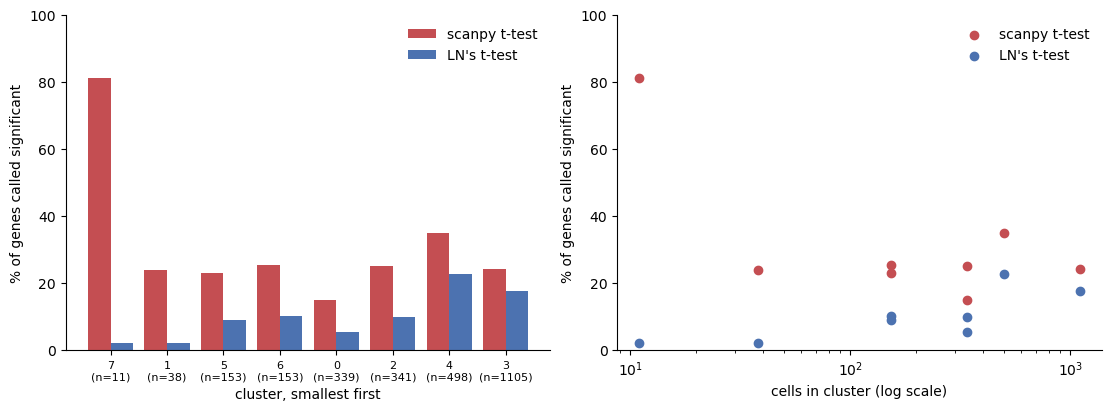

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

x = np.arange(len(counts))
order = counts.sort_values("n_cells").index
sub = counts.loc[order]

ax1.bar(x - 0.2, sub["t-test %"], 0.4, label="scanpy t-test", color="#c44e52")
ax1.bar(x + 0.2, sub["LN %"], 0.4, label="LN's t-test", color="#4c72b0")
ax1.set_xticks(x, [f"{c}\n(n={n})" for c, n in zip(order, sub["n_cells"])], fontsize=8)
ax1.set_ylim(0, 100)
ax1.set_ylabel("% of genes called significant")
ax1.set_xlabel("cluster, smallest first")
ax1.legend(frameon=False)

ax2.scatter(sub["n_cells"], sub["t-test %"], color="#c44e52", label="scanpy t-test")
ax2.scatter(sub["n_cells"], sub["LN %"], color="#4c72b0", label="LN's t-test")
ax2.set_xscale("log")
ax2.set_ylim(0, 100)
ax2.set_xlabel("cells in cluster (log scale)")
ax2.set_ylabel("% of genes called significant")
ax2.legend(frameon=False)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

## Confidence intervals

`rank_genes_groups_ln` also returns `lfc_se`, the standard error of each log-fold change, which
scanpy's ranking has no counterpart for. An interval follows directly:

$$\text{lfc} \pm 1.96 \times \text{lfc\_se}$$

Because the reported statistic is the log-fold change divided by that standard error, the interval
and the test agree by construction: a gene's interval excludes zero exactly when its statistic
exceeds 1.96.

In [7]:
cluster = clusters[0]
top = pd.DataFrame(
    {
        "gene": np.asarray(adata.uns["ln"]["names"][cluster])[:8],
        "lfc": np.asarray(adata.uns["ln"]["logfoldchanges"][cluster])[:8],
        "se": np.asarray(adata.uns["ln"]["lfc_se"][cluster])[:8],
    }
)
top["ci_low"] = top.lfc - 1.96 * top.se
top["ci_high"] = top.lfc + 1.96 * top.se
top.round(3)

,gene,lfc,se,ci_low,ci_high
0,CCL5,3.617,0.126,3.369,3.864
1,B2M,0.676,0.030,0.618,0.734
2,CD8A,3.497,0.173,3.158,3.837
3,GZMK,4.230,0.227,3.786,4.675
4,GZMA,2.539,0.142,2.261,2.818
5,IL32,1.544,0.087,1.373,1.715
6,GZMH,3.783,0.222,3.348,4.218
7,HLA-C,0.831,0.049,0.734,0.928


## The top ranked genes

In [8]:
TOP_N = 25

overlap = pd.Series(
    {
        c: len(
            set(np.asarray(adata.uns["ttest"]["names"][c])[:TOP_N])
            & set(np.asarray(adata.uns["ln"]["names"][c])[:TOP_N])
        ) / TOP_N
        for c in clusters
    },
    name=f"top-{TOP_N} overlap",
)
overlap.round(2).to_frame().T

,0,1,2,3,4,5,6,7
top-25 overlap,0.76,0.48,0.72,0.76,0.72,0.76,0.76,0.6


While sharing a large proportion of genes in their top ranks, the two methods differ in the genes they most confidently call as differentially expressed.